# Classification (Predict Diabetes)

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [21]:
df = pd.read_csv("../data/processed/processed_full_data.csv")

In [22]:
X = df.drop(columns=['Diabetes_binary', 'Diabetes_012'])
y = df['Diabetes_binary']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [26]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

Accuracy: 0.8494165878271839

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.97      0.92     42741
           1       0.56      0.20      0.29      7995

    accuracy                           0.85     50736
   macro avg       0.71      0.58      0.60     50736
weighted avg       0.82      0.85      0.82     50736



In [27]:
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

ROC-AUC: 0.8183723335308521


In [28]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [29]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

y_prob_rf = rf_model.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Accuracy: 0.8436810154525386

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.96      0.91     42741
           1       0.51      0.22      0.31      7995

    accuracy                           0.84     50736
   macro avg       0.69      0.59      0.61     50736
weighted avg       0.81      0.84      0.82     50736

ROC-AUC: 0.7927499243190864


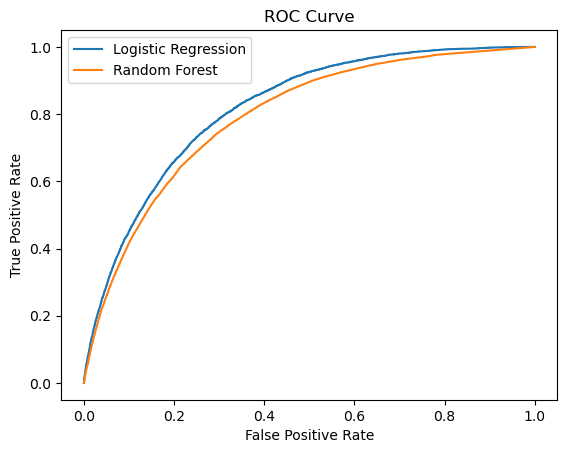

In [30]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure()
plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [31]:
importances = rf_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

importance_df.head(10)

,Feature,Importance
3,BMI,0.154197
18,Age,0.119747
20,Income,0.099490
15,PhysHlth,0.076217
19,Education,0.071425
14,MentHlth,0.058524
13,GenHlth,0.050175
0,HighBP,0.040426
8,Fruits,0.034439
4,Smoker,0.034430


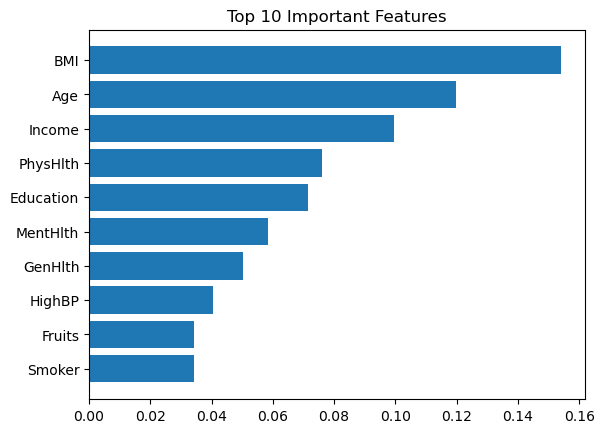

In [32]:
top_features = importance_df.head(10)

plt.figure()
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

In [33]:
import joblib

In [34]:
joblib.dump(rf_model, "../models/random_forest_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [35]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

In [36]:
importance_df.to_csv("../data/processed/feature_importance.csv", index=False)

In [37]:
metrics = {
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "roc_auc": roc_auc_score(y_test, y_prob_rf)
}

In [38]:
with open("../data/processed/model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

In [40]:
import pickle

# Save the model
with open("../models/random_forest_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)  # replace rf_model with your actual variable name

# Save the scaler
with open("../models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)  # replace scaler with your actual variable name